# CS4420 Project 1: Deep Learning on FashionMNIST
## Name: Gabriel Moeller
## Course: CS4420 Spring 2026
This project was made with assistance from ChatGPT, and checked by Claude

In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu
CUDA available: False


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [6]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100.0%
100.0%
100.0%
100.0%

Training samples: 60000
Test samples: 10000


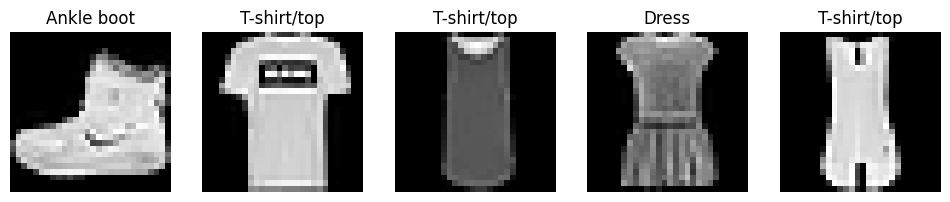

In [7]:
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = train_dataset[i]
    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(classes[label])
    axes[i].axis("off")

plt.show()

## Task 1: CNN Implementation

In this section, I implement the required convolutional neural network (CNN) in PyTorch for the FashionMNIST dataset. The model follows the project specification and is printed afterward so the architecture can be checked.

In [9]:
import torch
import torch.nn as nn

class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # First convolutional block:
        # Input: 1 x 28 x 28
        # Output after Conv1: 32 x 28 x 28
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # First max-pooling layer:
        # Output after Pool1: 32 x 14 x 14
        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Second convolutional block:
        # Output after Conv2:
        # using padding=2
        # Input 32 x 14 x 14 -> Output 64 x 16 x 16
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=2
        )

        # Second max-pooling layer:
        # Output after Pool2: 64 x 8 x 8
        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Third convolutional block:
        # Input 64 x 8 x 8 -> Output 64 x 8 x 8
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Third max-pooling layer:
        # Output after Pool3: 64 x 4 x 4
        self.pool3 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Flattened size:
        # 64 * 4 * 4 = 1024
        self.fc1 = nn.Linear(64 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        # ReLU activation used between layers
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass input through first conv block
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)

        # Pass through second conv block
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)

        # Pass through third conv block
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool3(x)

        # Flatten the feature maps into a single vector per image
        x = torch.flatten(x, start_dim=1)

        # Pass through fully connected layers
        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        # Do NOT apply softmax here because CrossEntropyLoss
        # expects raw logits
        return x

In [10]:
model = FashionCNN().to(device)
print(model)

FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [11]:
sample_images, sample_labels = next(iter(DataLoader(train_dataset, batch_size=4)))
sample_images = sample_images.to(device)

outputs = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([4, 1, 28, 28])
Output shape: torch.Size([4, 10])


## Task 1 Notes

The CNN was implemented in PyTorch according to the project specification. One important implementation detail is that although the architecture table lists softmax, I do not apply a softmax layer in the model's forward pass because PyTorch's `CrossEntropyLoss` already applies the appropriate operation internally to raw output logits.

## Task 2: Train/Validation Split Experiments

In this section, I train and test the CNN using different train/validation split settings. I first train the model with no validation set, then compare that to validation splits of 10%, 20%, 30%, and 40%.

In [12]:
# Use the assignment-required loss function
criterion = nn.CrossEntropyLoss()

# Keep these fixed
BATCH_SIZE = 64
EPOCHS = 10

In [13]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    # Put model in training mode
    model.train()

    # Track total loss, correct predictions, and number of samples
    running_loss = 0.0
    correct = 0
    total = 0

    # Loop through each batch
    for images, labels in dataloader:
        # Move data to CPU or GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass: get model predictions
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass: compute gradients
        loss.backward()

        # Update weights
        optimizer.step()

        # Add this batch's loss to the running total
        running_loss += loss.item() * images.size(0)

        # Get predicted class for each image
        _, predicted = torch.max(outputs, 1)

        # Update total and correct counts
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Compute average loss and accuracy for the epoch
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [14]:
def evaluate_model(model, dataloader, criterion, device):
    # Put model in evaluation mode
    model.eval()

    # Track total loss, correct predictions, and number of samples
    running_loss = 0.0
    correct = 0
    total = 0

    # Turn off gradient calculation for evaluation
    with torch.no_grad():
        for images, labels in dataloader:
            # Move data to CPU or GPU
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)

            # Add this batch's loss to total
            running_loss += loss.item() * images.size(0)

            # Get predicted class
            _, predicted = torch.max(outputs, 1)

            # Update counters
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Compute average loss and accuracy
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [15]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs):
    # Lists to store results for each epoch
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    # Repeat training for the requested number of epochs
    for epoch in range(epochs):
        # Train on training data
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Save training results
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # If validation loader exists, evaluate on validation set
        if val_loader is not None:
            val_loss, val_acc = evaluate_model(
                model, val_loader, criterion, device
            )
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
            )
        else:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}"
            )

    return history

In [16]:
def test_accuracy(model, test_loader, device):
    # Put model in evaluation mode
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            # Move batch to device
            images = images.to(device)
            labels = labels.to(device)

            # Get outputs
            outputs = model(images)

            # Predicted class is the index with the largest score
            _, predicted = torch.max(outputs, 1)

            # Update counts
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Return accuracy
    return correct / total

In [17]:
# DataLoader for full training set
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# DataLoader for test set
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Create a fresh model
model = FashionCNN().to(device)

# SGD with learning rate 0.1 for this experiment
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Train model without a validation set
history_no_val = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=None,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS
)

# Evaluate on test set
test_acc_no_val = test_accuracy(model, test_loader, device)
print("Test Accuracy (No Validation Set):", test_acc_no_val)

Epoch 1/10 | Train Loss: 0.9240 | Train Acc: 0.6477
Epoch 2/10 | Train Loss: 0.4357 | Train Acc: 0.8359
Epoch 3/10 | Train Loss: 0.3462 | Train Acc: 0.8716
Epoch 4/10 | Train Loss: 0.3005 | Train Acc: 0.8878
Epoch 5/10 | Train Loss: 0.2703 | Train Acc: 0.8992
Epoch 6/10 | Train Loss: 0.2474 | Train Acc: 0.9081
Epoch 7/10 | Train Loss: 0.2284 | Train Acc: 0.9152
Epoch 8/10 | Train Loss: 0.2107 | Train Acc: 0.9207
Epoch 9/10 | Train Loss: 0.1987 | Train Acc: 0.9253
Epoch 10/10 | Train Loss: 0.1865 | Train Acc: 0.9296
Test Accuracy (No Validation Set): 0.9096


### No-Validation Result

When the model was trained using the full training set with no validation split, it achieved a final training accuracy of **0.9296** and a test accuracy of **0.9096** after 10 epochs. This shows that the CNN was able to learn useful image features from the FashionMNIST dataset and perform well on unseen test data.

### What this code does

This code defines reusable functions for training and evaluating the CNN. It then performs an initial experiment using the full FashionMNIST training set with no validation set, as required in Task 2. The model is trained using SGD with learning rate 0.1 and cross-entropy loss, and test accuracy is reported at the end.

In [18]:
def create_train_val_loaders(dataset, val_ratio, batch_size):
    # Total number of samples in the original training set
    total_size = len(dataset)

    # Number of validation samples
    val_size = int(total_size * val_ratio)

    # Number of training samples left over
    train_size = total_size - val_size

    # Randomly split the dataset
    train_subset, val_subset = random_split(dataset, [train_size, val_size])

    # Create loaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

In [19]:
split_results = []

# Test loader stays the same
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# First result: no validation set
split_results.append({
    "validation_ratio": 0.0,
    "test_accuracy": test_acc_no_val
})

# Now try 10%, 20%, 30%, and 40% validation splits
for val_ratio in [0.1, 0.2, 0.3, 0.4]:
    print(f"\nRunning experiment with validation ratio = {val_ratio}")

    # Create loaders for this split
    train_loader, val_loader = create_train_val_loaders(
        train_dataset, val_ratio, BATCH_SIZE
    )

    # Fresh model for each experiment
    model = FashionCNN().to(device)

    # SGD with required learning rate
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    # Train model
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS
    )

    # Test trained model
    test_acc = test_accuracy(model, test_loader, device)

    # Save result
    split_results.append({
        "validation_ratio": val_ratio,
        "test_accuracy": test_acc
    })

    print(f"Test Accuracy for validation ratio {val_ratio}: {test_acc:.4f}")


Running experiment with validation ratio = 0.1
Epoch 1/10 | Train Loss: 0.9229 | Train Acc: 0.6459 | Val Loss: 0.5132 | Val Acc: 0.8108
Epoch 2/10 | Train Loss: 0.4505 | Train Acc: 0.8299 | Val Loss: 0.4221 | Val Acc: 0.8412
Epoch 3/10 | Train Loss: 0.3650 | Train Acc: 0.8632 | Val Loss: 0.3506 | Val Acc: 0.8705
Epoch 4/10 | Train Loss: 0.3189 | Train Acc: 0.8814 | Val Loss: 0.3320 | Val Acc: 0.8775
Epoch 5/10 | Train Loss: 0.2897 | Train Acc: 0.8914 | Val Loss: 0.3077 | Val Acc: 0.8883
Epoch 6/10 | Train Loss: 0.2663 | Train Acc: 0.8996 | Val Loss: 0.2888 | Val Acc: 0.8917
Epoch 7/10 | Train Loss: 0.2472 | Train Acc: 0.9069 | Val Loss: 0.2943 | Val Acc: 0.8900
Epoch 8/10 | Train Loss: 0.2315 | Train Acc: 0.9141 | Val Loss: 0.2679 | Val Acc: 0.9015
Epoch 9/10 | Train Loss: 0.2187 | Train Acc: 0.9182 | Val Loss: 0.2625 | Val Acc: 0.9022
Epoch 10/10 | Train Loss: 0.2067 | Train Acc: 0.9232 | Val Loss: 0.2771 | Val Acc: 0.9003
Test Accuracy for validation ratio 0.1: 0.8956

Running exper

In [20]:
for result in split_results:
    print(
        f"Validation Ratio: {result['validation_ratio']:.1f} | "
        f"Test Accuracy: {result['test_accuracy']:.4f}"
    )

Validation Ratio: 0.0 | Test Accuracy: 0.9096
Validation Ratio: 0.1 | Test Accuracy: 0.8956
Validation Ratio: 0.2 | Test Accuracy: 0.8949
Validation Ratio: 0.3 | Test Accuracy: 0.9040
Validation Ratio: 0.4 | Test Accuracy: 0.8992


### Analysis

The results show that the model achieved the highest overall test accuracy when no validation set was used. In that setting, the model trained on the full 60,000-image training set and reached a test accuracy of **0.9096**.

Among the experiments that used a validation split, the **30% validation ratio** performed the best, with a test accuracy of **0.9040**. The 10% and 20% validation splits gave slightly lower test accuracies, while the 40% split also performed below the no-validation baseline.

## Task 3: Learning Rate Experiments

In this section, I evaluate how different learning rates affect model performance. Based on Task 2, I use the 30% validation split and test SGD with learning rates of 0.001, 0.01, 0.1, 1, and 10.

In [21]:
# Create the best train/validation split from Task 2
best_val_ratio = 0.3

train_loader, val_loader = create_train_val_loaders(
    train_dataset, best_val_ratio, BATCH_SIZE
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [22]:
learning_rate_results = []

for lr in [0.001, 0.01, 0.1, 1, 10]:
    print(f"\nRunning experiment with learning rate = {lr}")

    # Fresh model for each learning rate
    model = FashionCNN().to(device)

    # SGD with current learning rate
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Train the model
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS
    )

    # Test accuracy
    test_acc = test_accuracy(model, test_loader, device)

    learning_rate_results.append({
        "learning_rate": lr,
        "test_accuracy": test_acc
    })

    print(f"Test Accuracy for learning rate {lr}: {test_acc:.4f}")


Running experiment with learning rate = 0.001
Epoch 1/10 | Train Loss: 2.3036 | Train Acc: 0.0997 | Val Loss: 2.3024 | Val Acc: 0.1007
Epoch 2/10 | Train Loss: 2.3025 | Train Acc: 0.0997 | Val Loss: 2.3014 | Val Acc: 0.1007
Epoch 3/10 | Train Loss: 2.3015 | Train Acc: 0.0997 | Val Loss: 2.3005 | Val Acc: 0.1007
Epoch 4/10 | Train Loss: 2.3005 | Train Acc: 0.0997 | Val Loss: 2.2995 | Val Acc: 0.1007
Epoch 5/10 | Train Loss: 2.2994 | Train Acc: 0.0997 | Val Loss: 2.2985 | Val Acc: 0.1007
Epoch 6/10 | Train Loss: 2.2982 | Train Acc: 0.0997 | Val Loss: 2.2972 | Val Acc: 0.1007
Epoch 7/10 | Train Loss: 2.2968 | Train Acc: 0.0997 | Val Loss: 2.2956 | Val Acc: 0.1007
Epoch 8/10 | Train Loss: 2.2948 | Train Acc: 0.1005 | Val Loss: 2.2935 | Val Acc: 0.1043
Epoch 9/10 | Train Loss: 2.2924 | Train Acc: 0.1371 | Val Loss: 2.2907 | Val Acc: 0.1948
Epoch 10/10 | Train Loss: 2.2890 | Train Acc: 0.2308 | Val Loss: 2.2866 | Val Acc: 0.2752
Test Accuracy for learning rate 0.001: 0.2725

Running experim

In [23]:
for result in learning_rate_results:
    print(
        f"Learning Rate: {result['learning_rate']} | "
        f"Test Accuracy: {result['test_accuracy']:.4f}"
    )

Learning Rate: 0.001 | Test Accuracy: 0.2725
Learning Rate: 0.01 | Test Accuracy: 0.7960
Learning Rate: 0.1 | Test Accuracy: 0.8904
Learning Rate: 1 | Test Accuracy: 0.1000
Learning Rate: 10 | Test Accuracy: 0.1000


### Analysis

The learning-rate experiment shows that model performance depends heavily on the step size used by SGD. The best test accuracy was achieved with a learning rate of **0.1**, which produced a test accuracy of **0.8904**.

The smaller learning rates of **0.001** and **0.01** performed worse. In particular, **0.001** learned very slowly and only reached a test accuracy of **0.2725** after 10 epochs, suggesting that the updates were too small for efficient training. The learning rate **0.01** improved performance to **0.7960**, but it still did not match the performance of **0.1**.

The larger learning rates of **1** and **10** performed very poorly, each producing a test accuracy of **0.1000**. Since FashionMNIST has 10 classes, this is close to random guessing. This suggests that those learning rates were too large and caused training to become unstable, preventing the model from converging.

Based on these results, the best learning rate for the remaining experiments is **0.1**.

## Task 4: Training Algorithm Experiment

In this section, I compare SGD and Adam using the best settings found in the previous experiments. Based on Task 2 and Task 3, I use a validation split of 30% and a learning rate of 0.1.

In [24]:
# Recreate the best split
best_val_ratio = 0.3
best_learning_rate = 0.1

train_loader, val_loader = create_train_val_loaders(
    train_dataset, best_val_ratio, BATCH_SIZE
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [25]:
optimizer_results = []

for optimizer_name in ["SGD", "Adam"]:
    print(f"\nRunning experiment with optimizer = {optimizer_name}")

    # Fresh model
    model = FashionCNN().to(device)

    # Choose optimizer
    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=best_learning_rate)
    else:
        optimizer = optim.Adam(model.parameters(), lr=best_learning_rate)

    # Train model
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS
    )

    # Evaluate on test set
    test_acc = test_accuracy(model, test_loader, device)

    optimizer_results.append({
        "optimizer": optimizer_name,
        "test_accuracy": test_acc
    })

    print(f"Test Accuracy for {optimizer_name}: {test_acc:.4f}")


Running experiment with optimizer = SGD
Epoch 1/10 | Train Loss: 1.0842 | Train Acc: 0.5814 | Val Loss: 0.5953 | Val Acc: 0.7862
Epoch 2/10 | Train Loss: 0.4950 | Train Acc: 0.8143 | Val Loss: 0.6842 | Val Acc: 0.7397
Epoch 3/10 | Train Loss: 0.3996 | Train Acc: 0.8493 | Val Loss: 0.3795 | Val Acc: 0.8571
Epoch 4/10 | Train Loss: 0.3460 | Train Acc: 0.8704 | Val Loss: 0.4230 | Val Acc: 0.8434
Epoch 5/10 | Train Loss: 0.3103 | Train Acc: 0.8844 | Val Loss: 0.4485 | Val Acc: 0.8189
Epoch 6/10 | Train Loss: 0.2869 | Train Acc: 0.8909 | Val Loss: 0.3708 | Val Acc: 0.8595
Epoch 7/10 | Train Loss: 0.2618 | Train Acc: 0.9014 | Val Loss: 0.2751 | Val Acc: 0.9023
Epoch 8/10 | Train Loss: 0.2464 | Train Acc: 0.9068 | Val Loss: 0.2629 | Val Acc: 0.9032
Epoch 9/10 | Train Loss: 0.2316 | Train Acc: 0.9131 | Val Loss: 0.3674 | Val Acc: 0.8730
Epoch 10/10 | Train Loss: 0.2155 | Train Acc: 0.9193 | Val Loss: 0.3365 | Val Acc: 0.8859
Test Accuracy for SGD: 0.8779

Running experiment with optimizer = A

In [26]:
for result in optimizer_results:
    print(
        f"Optimizer: {result['optimizer']} | "
        f"Test Accuracy: {result['test_accuracy']:.4f}"
    )

Optimizer: SGD | Test Accuracy: 0.8779
Optimizer: Adam | Test Accuracy: 0.1000


### Analysis

The optimizer comparison shows that changing from SGD to Adam did **not** improve performance under the selected settings. Using the best train/validation split from Task 2 and the best learning rate from Task 3, the model achieved a test accuracy of **0.8779** with **SGD** but only **0.1000** with **Adam**.

This indicates that Adam performed very poorly in this experiment. Since FashionMNIST has 10 classes, a test accuracy of **0.1000** is close to random guessing. A likely reason is that the learning rate of **0.1**, which worked best for SGD, is too large for Adam. Adam often works better with smaller learning rates, so using the same learning rate for both optimizers made Adam unstable and prevented convergence.

Based on these results, **SGD remained the better training algorithm** for this assignment under the required settings.

## Task 5: AUC Evaluation

In this section, I evaluate the best trained CNN model using AUC instead of accuracy. I treat images with label **2** as positive examples and all other labels as negative examples, creating a one-vs-rest classification setting.

In [27]:
# Rebuild the best overall model from previous experiments:
# no validation set, SGD, learning rate 0.1

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

best_model = FashionCNN().to(device)
best_optimizer = optim.SGD(best_model.parameters(), lr=0.1)

history_best_model = train_model(
    model=best_model,
    train_loader=train_loader,
    val_loader=None,
    criterion=criterion,
    optimizer=best_optimizer,
    device=device,
    epochs=EPOCHS
)

Epoch 1/10 | Train Loss: 1.0330 | Train Acc: 0.6019
Epoch 2/10 | Train Loss: 0.4491 | Train Acc: 0.8303
Epoch 3/10 | Train Loss: 0.3567 | Train Acc: 0.8654
Epoch 4/10 | Train Loss: 0.3072 | Train Acc: 0.8841
Epoch 5/10 | Train Loss: 0.2737 | Train Acc: 0.8981
Epoch 6/10 | Train Loss: 0.2515 | Train Acc: 0.9062
Epoch 7/10 | Train Loss: 0.2321 | Train Acc: 0.9142
Epoch 8/10 | Train Loss: 0.2165 | Train Acc: 0.9196
Epoch 9/10 | Train Loss: 0.2019 | Train Acc: 0.9249
Epoch 10/10 | Train Loss: 0.1885 | Train Acc: 0.9302


In [28]:
def compute_auc_for_class_2(model, dataloader, device):
    model.eval()

    all_true_labels = []
    all_scores = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Raw outputs from the model
            outputs = model(images)

            # Convert logits to probabilities
            probabilities = torch.softmax(outputs, dim=1)

            # Score for class 2
            class_2_scores = probabilities[:, 2]

            # Convert labels to binary:
            # 1 if label == 2, otherwise 0
            binary_labels = (labels == 2).int()

            all_true_labels.extend(binary_labels.cpu().numpy())
            all_scores.extend(class_2_scores.cpu().numpy())

    auc = roc_auc_score(all_true_labels, all_scores)
    return auc

In [29]:
auc_class_2 = compute_auc_for_class_2(best_model, test_loader, device)
print("AUC for class 2 vs all other classes:", auc_class_2)

AUC for class 2 vs all other classes: 0.989663111111111


### Analysis

Using the best trained CNN model, I changed the testing setup from a 10-class accuracy evaluation to a one-vs-rest AUC evaluation. In this setting, images with label **2** were treated as positive examples, while all other labels were treated as negative examples.

The computed AUC was **0.9897**. This is very close to 1.0, which indicates that the model is highly effective at distinguishing class 2 images from all other classes. In other words, the trained CNN assigns higher scores to true class 2 images than to non-class-2 images almost all the time.

This result shows that even though the original task is a 10-class classification problem, the best model also performs extremely well when evaluated as a binary one-vs-rest classifier for class 2.

## Conclusion

In this project, I implemented a convolutional neural network in PyTorch and evaluated it on the FashionMNIST dataset. The CNN architecture followed the assignment specification and was trained using cross-entropy loss.

In the train/validation split experiment, the highest overall test accuracy was obtained when no validation set was used, reaching **0.9096**. Among the validation-based experiments, the **30% validation split** performed best with a test accuracy of **0.9040**, so that split was used for the later experiments.

In the learning-rate experiment, **0.1** was the best learning rate for SGD, producing the highest test accuracy among the tested values. Smaller learning rates such as **0.001** and **0.01** learned more slowly, while larger learning rates such as **1** and **10** caused training to fail and produced performance close to random guessing.

In the optimizer comparison, **SGD** outperformed **Adam** under the required settings. Adam performed very poorly when using the same learning rate of **0.1**, suggesting that this learning rate was too large for Adam and caused unstable training.

Finally, the best model was evaluated using **AUC** in a one-vs-rest setting where class **2** was treated as the positive class. The model achieved an AUC of **0.9897**, showing that it was highly effective at distinguishing class 2 images from all other classes.

Overall, the experiments show that CNN performance on FashionMNIST is strongly affected by training data allocation, learning rate choice, and optimizer selection. Among the tested settings, SGD with learning rate **0.1** gave the strongest overall performance.

## Summary of Results

- **Task 2**
  - No validation set: **0.9096**
  - 10% validation: **0.8956**
  - 20% validation: **0.8949**
  - 30% validation: **0.9040**
  - 40% validation: **0.8992**

- **Task 3**
  - Learning rate 0.001: **0.2725**
  - Learning rate 0.01: **0.7960**
  - Learning rate 0.1: **0.8904**
  - Learning rate 1: **0.1000**
  - Learning rate 10: **0.1000**

- **Task 4**
  - SGD: **0.8779**
  - Adam: **0.1000**

- **Task 5**
  - AUC for class 2 vs all others: **0.9897**